### RCM Impact Report – Adjustment Analysis

This notebook presents the **RCM Impact Report**, which evaluates the financial effect of custom **projection adjustments** across:

- **Insurance Payors**  
- **Procedure Codes**  
- **States**
- **Census Changes**

The adjustments simulate expected changes such as:

- **Census growth/decline** (based on average revenue per patient)  
- **Rate shifts** by payor, procedure, or state

These projections are generated from the last 12 months of billing data and help identify areas of potential gain or loss when external conditions change.




### Project Overview

The **RCM Impact Report** is part of a broader Revenue Cycle Management (RCM) analytics platform built using **R Shiny**, **Plotly**, and **DT**.

This report focuses specifically on analyzing **projected revenue shifts** due to real-world business changes such as:

- Contract renegotiations with payors
- Adjustments in procedure mix
- Patient census fluctuations by state

The application allows users to:

- Upload their own financial data
- Select timeframes for historical and projected analysis
- Apply multiple adjustment series and simulate scenarios
- View interactive charts and tables that quantify impact

This notebook demonstrates the **back-end calculations** behind the impact summary, visualizations, and scenario modeling used in the live Shiny application.



###  Folder Structure & Modularity

The RCM Impact Report was designed with **modular R components** and a **well-organized folder structure** to support maintainability and scalability.

Below is an overview of the main folders and their roles:


📁 components/ # Modular UI and server logic ├── topMetrics.R # Summary value boxes for base, impact, and deltas ├── projection_plot.R # Projection adjustments, plot, and logic ├── impactStateBar.R # Bar chart for impact by State ├── impactPayorBar.R # Bar chart for impact by Payor ├── impactProcedureBar.R # Bar chart for impact by Procedure ├── data_table.R # Preview of the raw filtered data table

📁 utils/ # Supporting utility logic ├── data_mapping.R # Handles flexible column mapping ├── adjustments.R # Logic to add, modify, and delete projection adjustments

📄 server.R # Main application logic and reactive controls 📄 ui.R # Dashboard UI layout using shinydashboard 

##  Column Mapping Engine

When uploading data, users are prompted to map their columns to standard fields:

- Month
- Billed, Expected, Paid
- State, Facility
- Product, Payor
- Procedure, Service Type
- Unique Patient Count (optional)

This one-time mapping ensures compatibility with any dataset structure.


## Projection and Adjustment Logic

The projection engine models future revenue using the **last 12 months** of available data. It includes:

### 🔹 Base Forecast
- Derived from recent trends in the selected metric (`Billed`, `Expected`, or `Paid`).
- Optionally adjusted with an overall % growth rate.

### 🔹 Adjustment Series
Users can add one or more "what-if" adjustment series, each including:
- **Payor Adjustments**  
  - Targeted by Payor, Procedure, and State
  - Applied as percentage changes starting from a selected date
  - Weighted by historical mix share
- **Census Adjustments**  
  - Applied by State
  - Can be % growth or a flat patient increase
  - Uses per-patient revenue to estimate financial impact

### 🔹 Visualization
Each adjustment series is visualized alongside the base forecast for easy comparison. A summary table shows monthly projected values for each series.



##  Key Features

This Impact Report dashboard is designed to support healthcare analysts in evaluating financial shifts due to projected changes. Key functionality includes:

-  **Dynamic File Upload**
      - Upload any CSV and map its columns via the column mapping engine.

-  **Real-Time Forecast Visualization**
      - Compare base forecasts with one or more adjustment scenarios across time.

-  **Granular Adjustment Controls**
      - Apply payor- or census-level adjustments by procedure, state, or both.
      - Adjustments begin from a selected month and are weighted based on historical data.

-  **12-Month Rolling Impact Summary**
      - View the last 12 months of data adjusted forward with projected changes.

-  **Export / Import Adjustment Scenarios**
      - Save current adjustments to CSV (`Export Adjustments`)
      - Load saved scenarios back into the dashboard (`Import Adjustments`)
      - Enables sharing and reusing complex “what-if” scenarios across users or sessions.

-  **Impact Summary Metrics**
      - Delta, % Change, and Adjusted Totals shown for each adjustment series.

-  **Bar Charts for Impact by State, Payor, and Procedure**
      - Filtered views help pinpoint where the largest financial differences occur.

These features empower decision-makers to explore multiple revenue outcomes and understand how shifting variables impact projections.



## Development Notes

This dashboard was developed using modular R Shiny components for clarity, scalability, and ease of maintenance.

- **R Version**: 4.x  
- **Libraries Used**:
  - `shiny`, `shinydashboard`, `DT`, `plotly`, `dplyr`, `lubridate`, `uuid`, `tidyverse`

- **Design Principles**:
  - **Modular Codebase**: Each chart or logic unit resides in its own file under `components/` or `utils/`
  - **Column Mapping Flexibility**: Any dataset can be adapted to work using the mapping modal
  - **Dynamic UI**: Selectors and inputs update automatically based on the uploaded dataset

- **Deployment Ready**:
  - Can be deployed locally or on **shinyapps.io**
  - Docker-compatible for scalable hosting on **AWS EC2** or **Posit Connect**

- **Data Expectations**:
  - Input file must include a **Month** column and values for **Billed**, **Expected**, and **Paid**
  - Instead of raw patient IDs, the dataset must include a pre-aggregated **NumPatients** field  
    (i.e., number of unique patients per month per group)
  - Data should be grouped and summarized in advance by:
    - `State`
    - `Facility`
    - `Payor`
    - `Payor Type` (e.g., Medicare, Commercial, Medicaid)
    - `Procedure Code`
    - `Procedure Type` (e.g., MED, BEH, LAB)

> A separate **Payor Data Preparation Program** is available to transform raw claims data into the properly structured report format required for this dashboard. This companion tool performs all necessary aggregation and enrichment to ensure compatibility.

This modular and pre-aggregated design allows the dashboard to deliver fast and scalable insights even when working with millions of records.



##  How to Use the Impact Report

This dashboard helps you analyze how changes in reimbursement rates or patient volume affect financial performance over time. Here's a quick step-by-step overview:

1. ** Upload Your Data**  
   Upload a pre-aggregated CSV file containing grouped metrics like Billed, Expected, Paid, and NumPatients by State, Facility, Payor, Procedure Code, and Procedure Type.

2. ** Map Columns**  
   Use the column mapping modal to align your dataset fields with the dashboard's standard structure (Month, Payor, Expected, etc.).

3. ** Set Your Time Ranges**  
   Choose the overall reporting date range and the last 12 months to use as the baseline for projections.

4. ** Review Summary Metrics**  
   View baseline metrics like total expected revenue and collection rate in the top summary value boxes.

5. ** Create Impact Scenarios**  
   Use the **Adjust Projection** tool to simulate:
   - Payor rate shifts (by Payor + Code + State)
   - Census changes (volume increase or patient drop)

6. ** View the Impact**  
   Compare baseline vs. adjusted projections in the forecast plot and summary table. Explore the financial delta by Payor, Procedure, and State.

7. ** Save and Share**  
   Export your scenarios and their financial impact using the built-in **Export Adjustments** feature. Later, import them back in to continue modeling.

---

More detailed instructions are provided in the sections below.


##  Data Preparation Requirements

To ensure the dashboard functions properly and the projection model produces accurate results, all Accounts Receivable (AR) data **must be pre-aggregated** using the following grouping fields:

###  Required Grouping Fields:

- **Month** – Format: `YYYY-MM-DD` (use the **first day of the month** for consistency)
- **State** – Two-letter abbreviation representing where the service was provided
- **Facility** – Name or code identifying the service location
- **Payor** – The name of the insurance payor (e.g., Aetna, Medicare)
- **Payor Type** – Broad classification of the plan (e.g., Commercial, Medicare, Medicaid)
- **Insurance Product** – Specific plan (e.g., HMO, PPO, Medicare Advantage)
- **Procedure Type** – Broad category of service (e.g., LAB, MED, IMG, BEH)

---

Each unique combination of the above fields should include the following **aggregated numeric metrics**:

- `Billed` – Total amount billed  
- `Expected` – Expected reimbursement  
- `Paid` – Amount actually paid  
- `Unique Patients` – Number of unique patients **per state per month**

> ⚠️ **Important Note on Unique Patients**  
The `Unique Patients` column must represent the **distinct patient count for each month-state group**, and this number should be **duplicated across all rows** within that same group — regardless of payor, facility, or procedure breakdowns.

---

Properly grouped and formatted data ensures:
- Accurate forecast adjustments
- Correct payor/procedure impact visuals
- High performance and accuracy across all dashboard modules

>  Need help converting raw claim data?  
Use the **Payor Dashboard Data Formatter** — a separate tool that prepares raw data into this required format.



##  Column Mapping (Auto-Detection Modal)
**When it appears:**
- On first load or when uploading a file

**Function:**
- Automatically tries to match column names (e.g., 'Total_Billed' ≈ 'Billed')
- Users can override or confirm

**Columns Required:**
- Month
- Amount Billed
- Expected Amount
- Paid Amount
- State
- Facility
- Insurance Product
- Insurance Payor
- Procedure Code or Procedure Type
- Number of unique patients for the given row

>Column header names do not have to match.  The mapping function will map according to user's choice

**Tech:**
- Modal UI built using `shiny::modalDialog()`
- Matching logic in `utils/mapping.R`

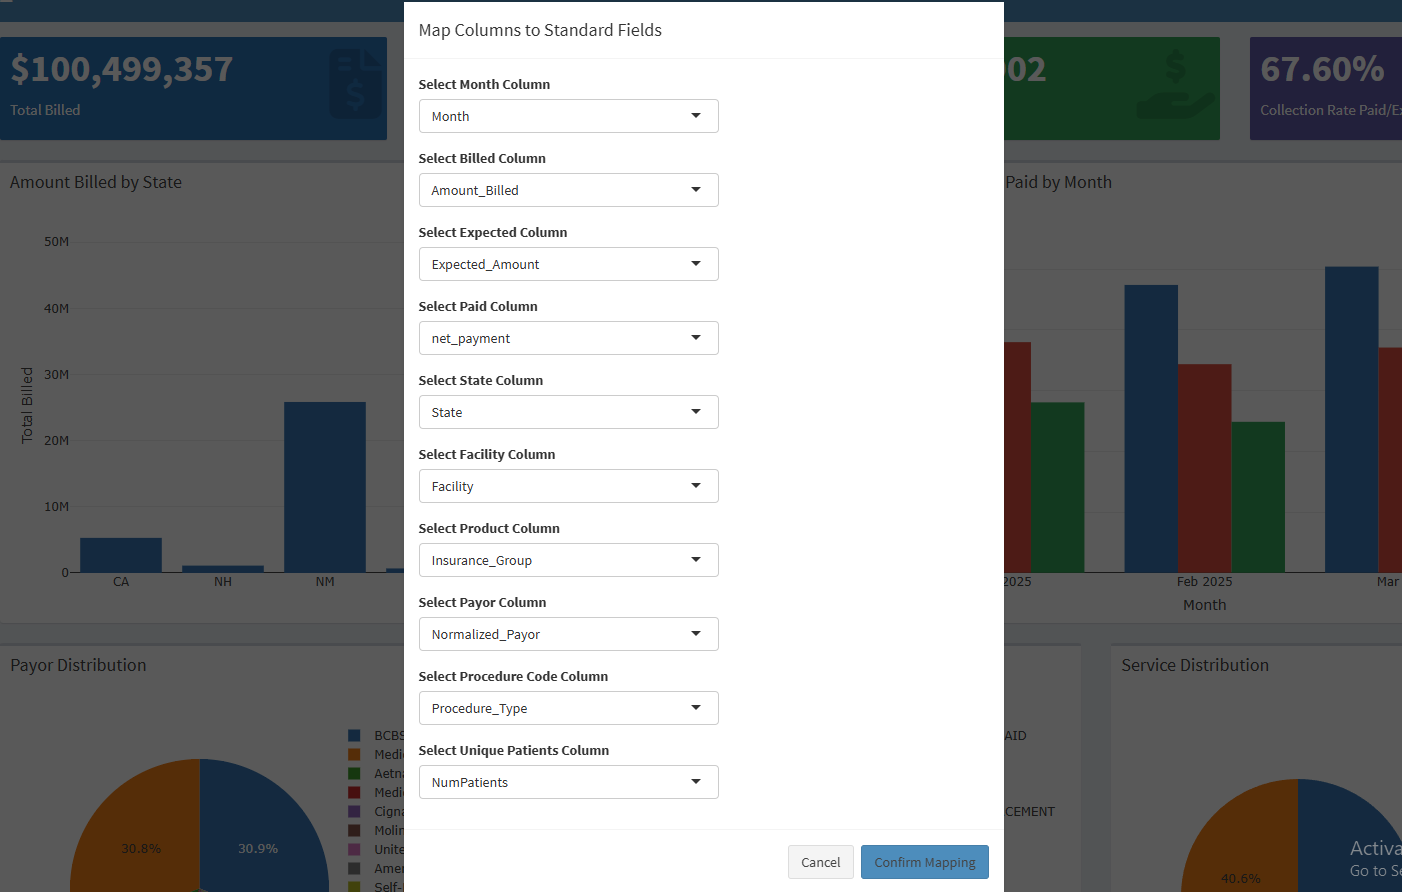

##  Date Range Controls (Top vs Bottom Inputs)

**There are two separate date range inputs in the dashboard, and they serve different but coordinated purposes.**

---

###  Top Date Range Input — `Date Range`
- This is the **main control** for the date range of the entire report.
- It defines the **range used for  projections**.
- The **projection chart only uses this date range**.

---

###  Bottom Date Range Input — `Report Date Range`
- This controls the range of **all other charts** (billing, expected, Payors, etc.).
- It defines what part of the data is **visible across the dashboard**, except for the projection.

---

###  Rule of Range Overlap: "The Smaller One Wins"
- If one date range ends before the other, **that smaller overlap is used** for most charts.
-  Example:
  - Top `Date Range`: **Jan 2023 – Mar 2024**
  - Bottom `Report Date Range`: **Jan 2023 – Jan 2024**
  -  The charts (except the projection) will show data only through **Jan 2024**.

- The **projection chart still uses the full top range**, even if other charts cut off sooner.

---

This setup allows you to:
- Analyze a **narrower period** on the dashboard
- While still projecting **beyond that period** in the forecast


##  Date Range Controls (Top vs Bottom Inputs)

There are **two separate date range inputs** in the Impact Report dashboard — both are essential for different aspects of analysis.

---

###  Top Date Range Input — `Date Range`
- This is the **primary input** that controls the **projection model**.
- The projection chart is based on the **last 12 months of data leading up to the end of this range**.
- The projection line uses these 12 months as the **baseline** before applying any adjustments.

 **Only the projection chart uses this top range.**

---

###  Bottom Date Range Input — `Report Date Range`
- This range controls the **reporting window** for the rest of the dashboard:
  - Pie charts
  - Impact bar charts
  - Value boxes
  - Data tables

- It filters the dataset to define what part of the **historical data** is used for measuring financial impact and visual insights.

---

###  Range Conflict Rule: *"The Smaller One Wins"*
If the two ranges don't fully overlap, the **shorter overlap is used** for most dashboard elements.

 **Example:**
- Top `Date Range`: **Jan 2023 – Mar 2024**
- Bottom `Report Date Range`: **Jan 2023 – Jan 2024**
- Result:
  - Charts and summaries show data through **Jan 2024**.
  - The **projection chart still uses the full 12 months leading up to Mar 2024**.

---

This dual control gives users the flexibility to:
- Run **forecasts into the future** (using Top)
- While analyzing the **measured impact in a specific window** (using Bottom)

---

##  Output Metric Selection

The dashboard includes an **Output Metric** dropdown for switching between:

- **Billed**
- **Expected**
- **Paid**

This controls the **entire context** of your analysis:

-  **Projection logic** (forecast and adjustments)
-  **Impact bar charts** (by Payor, State, and Procedure)
-  **Pie charts** and **Value boxes**
-  **Adjustment summary table**

###  Behind the scenes:
Whichever metric is selected is internally mapped to a column called `Value`, which ensures all modules stay synchronized — even when  switching metrics.

This allows seamless exploration of your **revenue exposure** across different financial definitions.



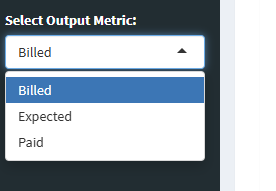

## Export Dashboard as PDF

---

### Purpose:
- Allows users to save a snapshot of the current dashboard for offline review, presentation, or record-keeping.

---

### How to Use:
1. On most browsers (Chrome, Edge, Firefox), right-click anywhere on the dashboard or press `Ctrl + P` (Windows) or `Cmd + P` (Mac) to bring up the **Print** dialog.
2. Set the **Destination** to “Save as PDF”.
3. Under **Layout**, select `Landscape` mode to best fit the dashboard’s wide format.
4. Click on **More Settings** (if available), and ensure:
   - **Scale** is set to `100` for a true-to-screen fit.
   - **Margins** are set to `None` or `Minimum` for edge-to-edge visuals.
   - **Headers and Footers** are turned **off** for a clean layout.

---

### Recommendations:
- Use full-screen mode (`F11` on most browsers) before printing to remove browser chrome.
- Filters applied in the dashboard (such as dates, payors, or output metric) will affect what is shown in the saved PDF.

---

This feature is ideal for printing summary reports or sharing static snapshots with leadership, clients, or auditors.


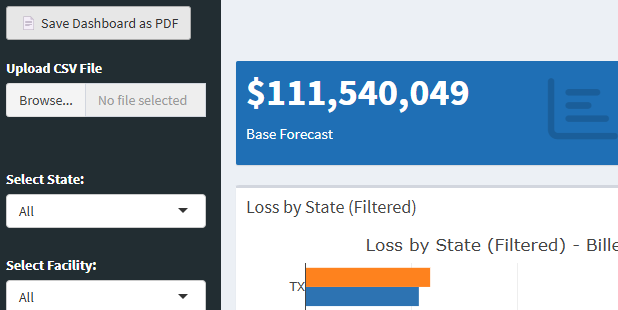

##  Impact Report – Top Metrics

The **topMetrics** section summarizes the financial impact of the current projection adjustments. This is the most important high-level view of your modeled scenarios.

---

###  **What the Value Boxes Show**

- **Base Forecast**  
  Represents the expected value across the forecast period **without** any adjustments (i.e., your historical baseline).

- **Adjusted Total**  
  The total value after applying the currently selected adjustment series (payor-level and census-level changes).

- **Impact (Δ $)**  
  The dollar difference between Adjusted Total and Base Forecast.  
  `Adjusted - Base`

- **Impact %**  
  The percentage difference compared to the base.  
  `(Adjusted - Base) / Base × 100%`

---

###  **How it Works**

- Based on the last 12 months from your **Date Range** (top input).
- The values shown reflect only the **currently selected adjustment series**.
- You can create and toggle between multiple adjustment scenarios using the projection tools.
- The table and charts below also respond to the same logic, ensuring consistency.

---

These value boxes are a quick and powerful way to understand **how much financial impact** your modeled changes would have—whether positive or negative.


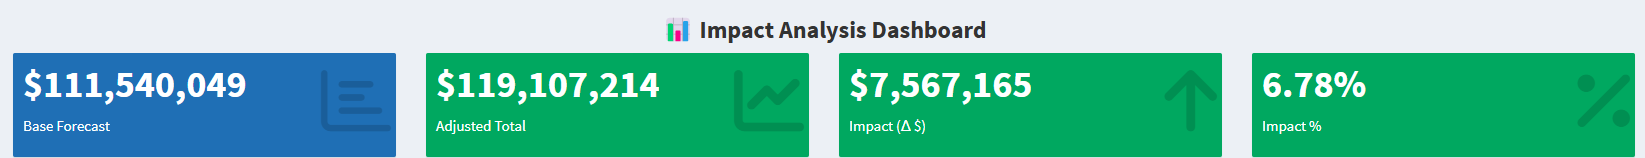

##  Loss Breakdown Charts (Filtered)

These three side-by-side bar charts show the **financial impact of projection adjustments** across key dimensions:

---

### 1️ **Loss by State (Filtered)**  
This chart displays how **Billed amounts** compare to **Adjusted values** per state.

- **Blue bar** = Total billed for each state under current filters  
- **Orange bar** = Adjusted projection after applying changes  
- Use this to see which **states are most impacted** by the adjustment scenario.

---

### 2️ **Loss by Payor (Filtered)**  
Compares billed vs. adjusted totals **per payor** (e.g., Medicare, Aetna, BCBS).

- Helps you identify which **insurance companies** are driving the largest projected change.
- Includes **Self-Pay** and **Medicaid/Medicare** categories.

---

### 3️ **Loss by Procedure Code (Filtered)**  
Breaks down impact by individual **CPT/Procedure Codes**.

- Reveals which procedures (e.g., 99215, 80307) are contributing most to the change.
- Useful for **targeting specific services** affected by reimbursement shifts or census fluctuations.

---

###  Notes:
- These charts **only use data that matches your dashboard filters**.
- The projection adjustment selected (from the series dropdown) will be reflected here.
- Metric shown is based on your selected output: `Billed`, `Expected`, or `Paid`.

Together, these charts provide a **granular view of projected financial impact** based on the adjustments applied.


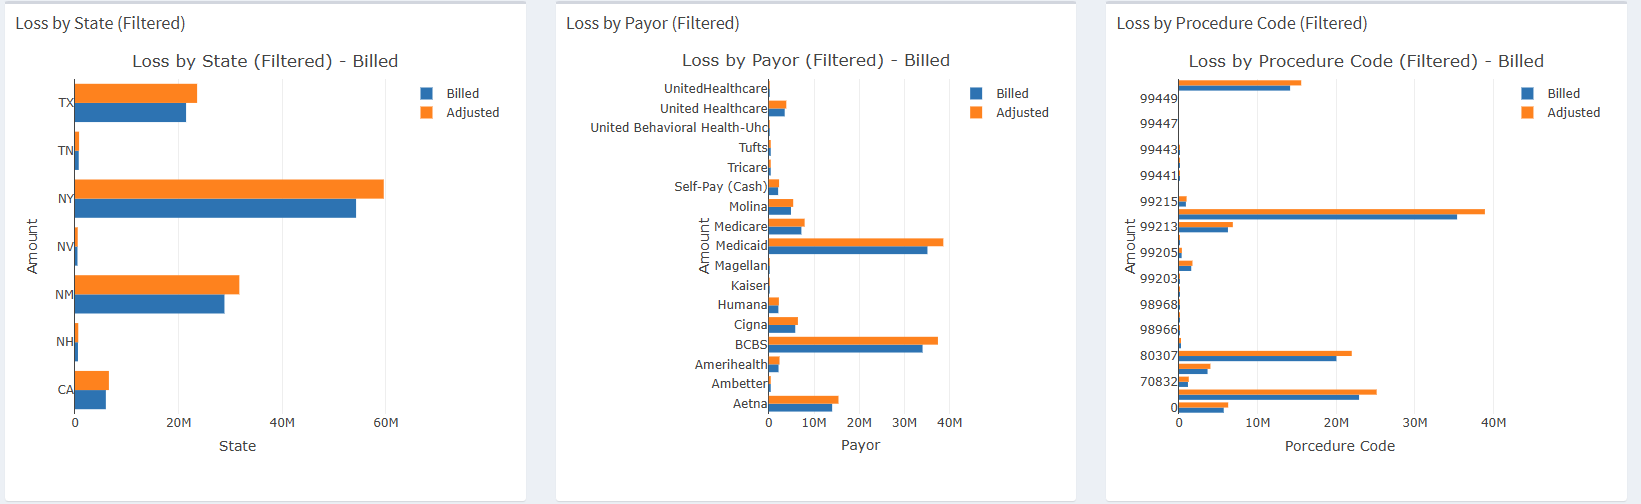

## Impact Projection Tools

The projection chart in this dashboard displays the **last 12 months of actual revenue data** with overlaid adjustment scenarios. This is not a traditional time series forecast — instead, it's a **scenario modeling tool** that simulates financial outcomes under various payor or census-driven changes.

---

### What It Shows

- The **base line** represents the last 12 months of actual totals (Billed, Expected, or Paid).
- Additional dotted lines represent **adjustment series** you define.
- Each line reflects **the impact of specific changes**, such as a payor dropping rates or patient volume growth in a region.

---

### Supported Adjustment Types

- **By Payor / Procedure / State**  
  Apply a **% change to revenue** based on a specific payor's historical share of the revenue mix for a given procedure and/or state.

- **By Census (Per State)**  
  Project revenue shifts based on **monthly patient growth**, either:
  - As a **percentage** (e.g., +5% per month),
  - Or a **flat increase** in number of patients.

---

### Timing & Start Date Logic

Each adjustment includes a **Start Date**. The dashboard will:

- Begin applying the change from that month forward
- Maintain historical values prior to the start date
- Automatically apply compounding or cumulative effects when applicable

---

### Managing Projection Series

- **New Series**: Create an independent adjustment scenario  
- **View Adjustments**: See and delete individual entries  
- **Delete Series**: Remove the selected scenario  
- **Series Selector**: Switch between saved scenarios for comparison

Each series runs **in parallel**, allowing **side-by-side comparisons**.

---

### Global Adjustment Tool

Apply a **universal % adjustment** to the base line (e.g., `-3%`) to reflect known operational changes like:

- Decreased reimbursement margins
- Staffing changes
- Payer contract reductions

---

### Adjustment Import / Export

- **Export Adjustments**: Save all adjustment series to a CSV file for sharing or backup.
- **Import Adjustments**: Load a previously saved adjustment file to reapply scenarios.

This makes it easy to replicate configurations across dashboards or share forecast strategies with other teams.

---

This modeling tool is ideal for:

- Evaluating **potential financial risk**
- Comparing **strategic outcomes**
- Communicating impacts of **rate changes or census shifts**

It transforms your actual revenue data into a **flexible planning tool** with full transparency into how each change affects the bottom line.




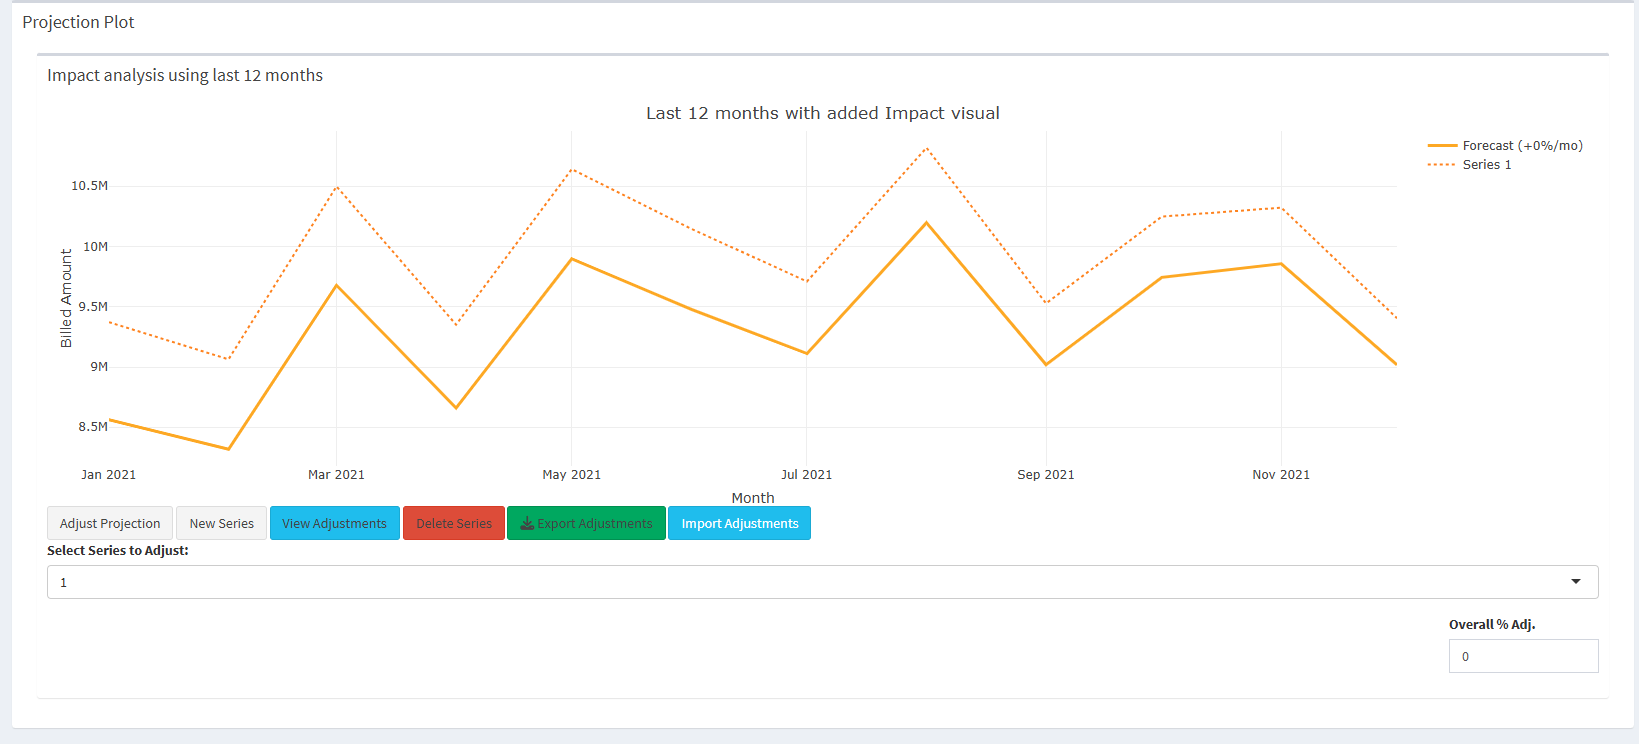

## Using the Projection Chart and Global Adjustment (% Shift)

The **Impact Projection Chart** shows the last 12 months of actual financial performance and allows users to simulate future changes. This tool is not a forecast model—it's a **scenario-based projection** built from historical data, allowing you to test the impact of different rate or census changes over time.

---

### What the Chart Shows

- A **baseline line** representing actual Billed, Expected, or Paid totals over the last 12 months.
- One or more **adjusted lines** that show the result of custom adjustment scenarios (e.g., payor rate changes, census increases).
- A comparison of **actual vs. adjusted** values to estimate financial risk or opportunity.

---

### Global % Shift (Bottom-Right Input)

Located in the bottom-right of the projection panel, the **Overall % Adj.** input applies a **monthly compounding growth rate** to the base line. This allows you to quickly simulate upward or downward revenue trends **before any individual adjustments are added**.

---

### How It Works

- The % shift is **applied cumulatively month-over-month** across the 12-month baseline.
- It does **not override** or conflict with individual payor or census adjustments.
- Adjustment series are layered **on top of** the globally shifted baseline.

---

### Use Cases

- Model **overall growth or decline** due to macroeconomic factors, new service lines, or internal strategy changes.
- Apply **broad assumptions** when the exact source of change isn’t yet known.
- Stress test budgets by applying systemic revenue lifts or cuts.

---

### Examples

- Entering `+2%` applies a 2% monthly increase that **accumulates over time**—roughly 26.8% higher by the 12th month.
- Entering `-3%` compounds to about a 30% total reduction over 12 months, simulating sustained underperformance.

> Use this as a fast tool to simulate **trend-based changes** without needing to configure detailed payor or census-level adjustments.



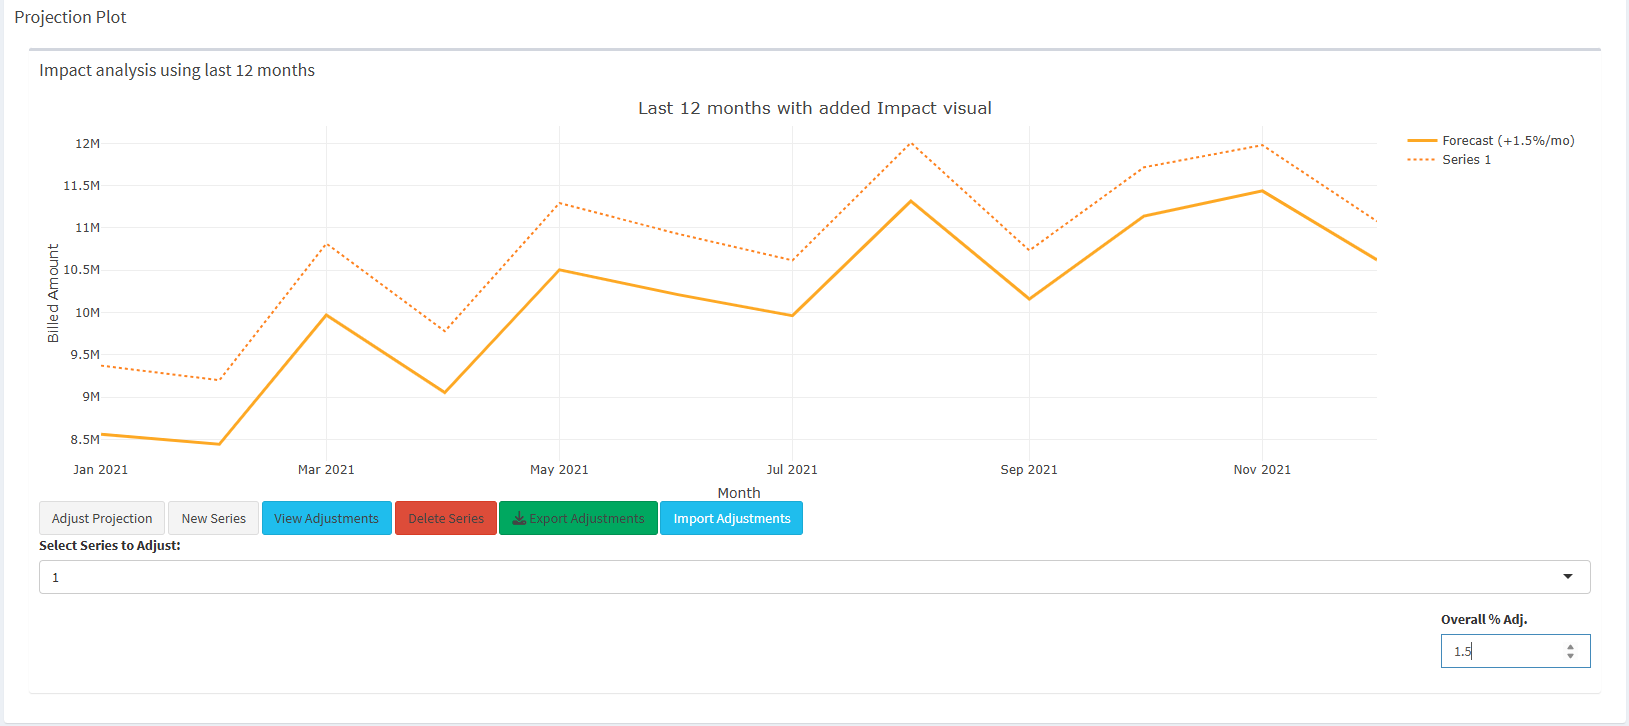

## Managing Projection Series: Add, Select, Delete, Export, and Import

The Impact Report dashboard allows you to create and modify **custom adjustment series** to simulate revenue changes. These series act as **"what-if" scenarios**, modeling the effect of payor rate changes, census growth, or both on your actual revenue baseline.

---

### Add a Series

- Click the **"New Series"** button to create a new projection series.
- Each series is shown as a **distinct dotted line** on the projection chart.
- Adjustments (Payor or Census) are linked directly to the **currently selected series**.

> ⚠️ **Important**: While multiple series can be added, only **Series 1** is currently supported for persistence and export/import.

---

### Select a Series

- Use the **"Select Series"** dropdown to choose which series to view or modify.
- Only **one series can be active at a time** for editing.
- The selected series will be used for all adjustment operations (add/view/delete).

---

### Delete a Series

- Click the **"Delete Series"** button to remove the active series.
- If **all series are deleted**, the projection chart will be empty until a new one is added.

---

### Top Metric Binding to Series 1

The **Top Metrics summary boxes** (Base Forecast, Adjusted Total, Impact Delta, Impact %) are **always tied to Series 1**.

Even if you are viewing or working in another series:
- The summary metrics will still reflect **Series 1's results only**.
- For now, Series 1 acts as the **primary evaluation layer** across the dashboard.

---

### Export Adjustments (Series 1 Only)

- Click the **"Export Adjustments"** button to download all adjustments in **Series 1** as a `.csv` file.
- This export includes:
  - All Payor-level changes
  - All Census adjustments
  - Associated start dates, percent shifts, and state-specific data

---

### Import Adjustments (Series 1 Only)

- Use the **"Import Adjustments"** button to upload a previously exported `.csv` file.
- The import will:
  - **Delete all existing series**
  - Load the adjustments into **Series 1 only**
  - Reset the projection chart accordingly

> 🚫 Currently, importing into multiple series is **not supported**. All imported data will be routed into Series 1 and overwrite existing content.

---

### Summary

- You can simulate unlimited combinations of Payor and Census adjustments in **Series 1**.
- Export/import lets you save and restore these scenarios for reuse or collaboration.
- Series management is designed to help teams test, tweak, and present financial scenarios with ease.


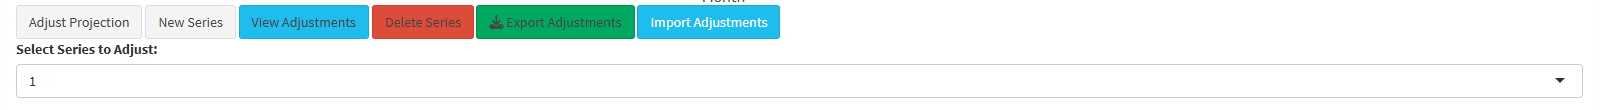

## Adding Adjustments to a Series (Impact Report)

The **Impact Report** models potential financial changes by applying targeted adjustments to the **last 12 months of actual revenue data**. These adjustments do not use a forecast model like ARIMA — instead, they simulate what would happen if known or hypothetical changes had occurred over that same period.

---

### How to Add an Adjustment

1. Select the active **Series** (only one at a time).
2. Click **"Adjust Projection"**.
3. Choose an **Adjustment Type**:
   - **Payor** – percentage-based revenue change
   - **Census** – patient volume growth
4. Fill out the fields, and click **"Add to Series"**.

---

### Payor Adjustment

This type of adjustment lets you simulate **rate changes** across:

- **Payor(s)** — One or more payors affected
- **Procedure Code(s)** — Specific CPT/HCPCS codes impacted
- **State(s)** — Regional targeting (e.g., NM, TX)

**Key Fields:**
- **Adjustment %** – The percentage change applied **each month independently** (not compounded).
- **Start Date** – When the adjustment begins affecting monthly totals.

**Important Behavior:**
- The percentage entered is applied to each matching month's **existing data**, **not as a compounding growth**.
- Each monthly impact is **flat** — i.e., a `+10%` adjustment increases each month's matched value by 10% regardless of previous months.

---

### Example

> Simulate a 10% drop in revenue from CPT code 99213 for Ambetter in TX, starting Jan 2020:
>
> - Payor(s): Ambetter  
> - Procedure(s): 99213  
> - State(s): TX  
> - Adjustment %: `-10`  
> - Start Date: `2020-01-01`

The dashboard will reduce the matched revenue values by 10% in **each month from Jan 2020 onward**, with no compounding.

---

### Notes

- You can add **many adjustments** to the same series to stack effects.
- Use `"All"` for Payor / Procedure / State to apply changes broadly.
- Adjustments only take effect **on and after the Start Date**.
- This is a powerful tool for modeling **rate reductions, contract changes, or coding shifts** without altering your raw data.




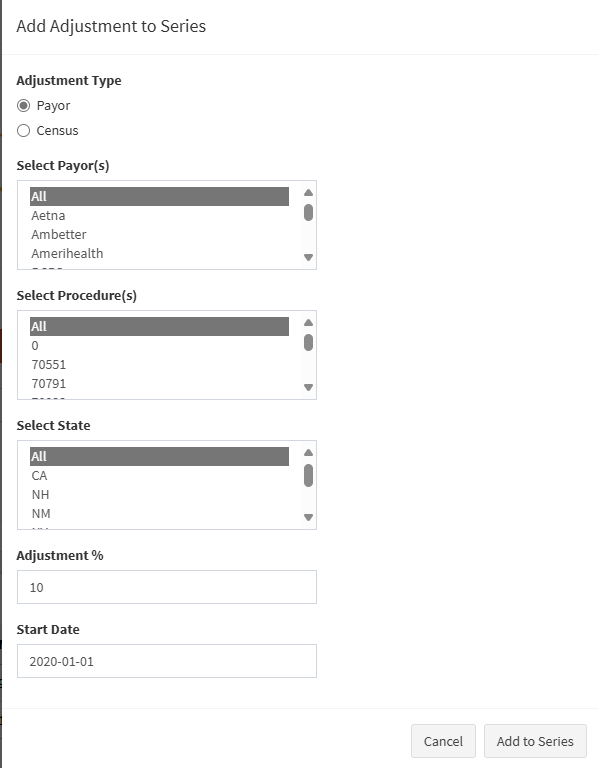

## Census Adjustment

The **Census Adjustment** models changes in patient volume across the last 12 months of actual data. Instead of targeting payors or procedures, this adjustment simulates the financial impact of growing or shrinking patient counts in a specific **state**.

---

### Fields:

- **Select State** – The state where census changes occur
- **% Growth** – A monthly **compounding** percentage increase or decrease
- **Census Count** – A fixed number of patients added per month
- **Start Date** – When the adjustment begins to apply

---

### How it Works:

- **Percentage Growth** is **compounded monthly** from the selected Start Date.
  - For example, `+5%` applies a 5% increase in patients for each month relative to the prior month.
- **Census Count** adds a **flat number of patients** to each month.
- If **both** are entered:
  - **Only the % Growth** is applied. It **overrides** the Census Count.

Each adjustment affects the **state’s share of total patients**, scaled by the **average revenue per patient** for that state and time period.

---

### Example

> Model 3% monthly census growth in NM starting July 2022:
>
> - State: NM  
> - % Growth: `+3`  
> - Start Date: `2022-07-01`

From July forward, each month’s revenue will increase based on the new patient count resulting from that 3% monthly growth. If revenue per patient is $1,000 and the state previously had 500 patients, that month would add 15 new patients and $15,000 to the adjusted value.

---

### Why It’s Useful

This adjustment is ideal for:

- Modeling **new program launches** or **geographic expansions**
- Simulating **seasonal patient growth**
- Estimating **staffing-driven changes** in volume

It offers a clean way to visualize the operational impact of census shifts at the regional level — using your actual historical data as the base.

---


## Example: Layering Census Adjustments

This chart visualizes how **multiple census adjustments** can interact and influence the projected revenue line over the last 12 months.

---

### What’s Shown

- **Solid Line**: Baseline projection with a global **+1.5% monthly growth** applied.
- **Dotted Line ("Series 1")**: Custom scenario reflecting user-defined **census-based adjustments**.

---

### Applied Adjustments in his Example

1. **Census Increase of +1000 Patients**  
   - **Effect**: A sudden, visible jump in revenue starting from the specified start date.  
   - **Why**: The added patients are multiplied by the state’s average revenue per patient, leading to a sharp increase.

2. **Census Decrease of -3% per Month**  
   - **Effect**: After the initial jump, the dotted line **begins trending downward** due to the compounding effect of the 3% monthly reduction in census.  
   - **Why**: Each subsequent month loses 3% of the previous month's patient volume, which pulls the revenue line down over time.

---

### Interpretation

This scenario models a **growth event followed by a slow erosion**, such as:

- A new site opening or large contract win (1000 patient boost),
- Followed by staffing losses, reduced referrals, or payer exit (-3% monthly decline).

It demonstrates how the dashboard allows you to **layer multiple effects** and immediately see their combined financial impact — empowering data-driven planning and risk analysis.



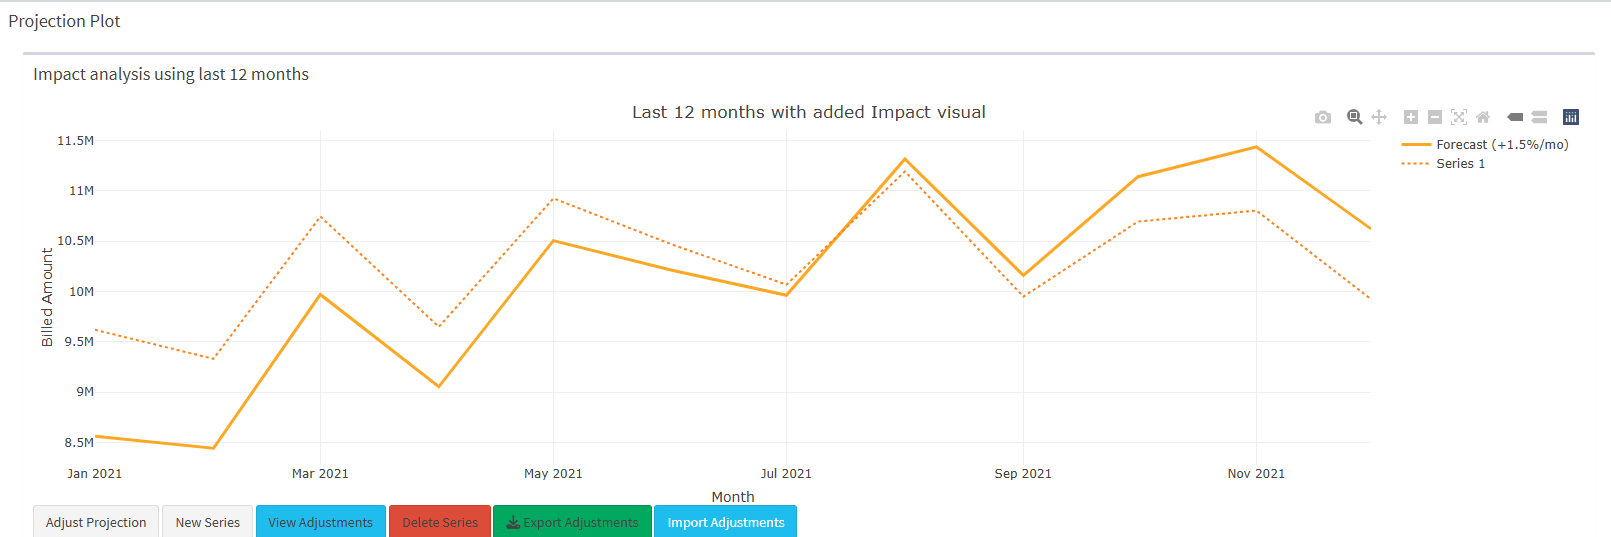

## Projection Table Overview

The **Projection Table** displays the detailed monthly values for each projection series shown in the chart above.

---

### What the Table Shows

Each row represents a forecast scenario:

- **Base Forecast** – This is the original projection based on historical trends and optional global shift (% growth) input.
- **Series 1** – This includes all adjustments (Payor- or Census-based) applied to the first scenario. Additional series will appear in separate rows if supported.

Each column represents a **month**, formatted as `MMM_YYYY`, showing the projected revenue (Billed, Expected, or Paid, depending on selected metric).

---

### Purpose

This table allows you to:

- **Compare numeric results** side-by-side between different projection scenarios.
- **Validate the impact** of your adjustments month-by-month.
- Spot trends, dips, or spikes caused by changes in payor mix, volume growth, or reimbursement.

---

### Example

- **July 2021**:
  - Base Forecast: `$9,962,744`
  - Series 1: `$10,067,873`
  - → Indicates that the adjustments pushed July’s projection up by **$105,129**

---

### Notes

- All values are rounded and formatted for readability.
- This view is ideal for stakeholders who prefer **data tables** over visual charts.
- A more **detailed and exportable version of this table is under development** and will be available in future releases.



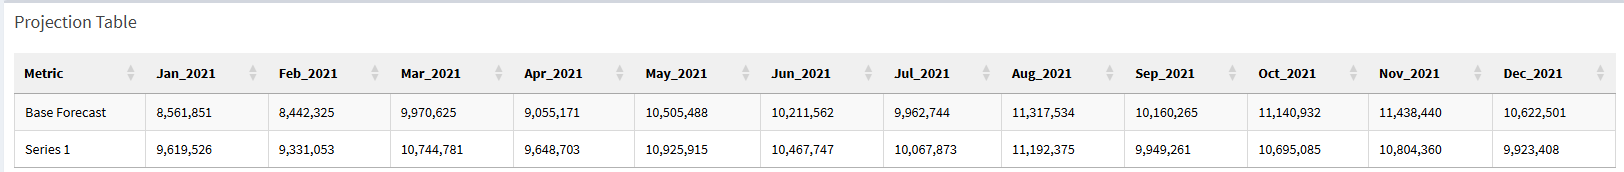


###  Adjustment Mechanics
- Adjustments apply **only to the currently selected series**.
- Each adjustment has its **own start date** and takes effect independently.
- You can apply **multiple adjustments to one series** for layered, scenario-based modeling.
- Adjustments can be **viewed and deleted individually** using the adjustment list panel.

---

###  Example Scenarios
- **Jan 2024** → Payor A receives **+5% rate increase**
- **Apr 2024** → Texas census grows by **3% monthly**, plus **15 new patients/month**

→ Your projection line will reflect **both** adjustments starting on their respective dates, with real impact based on the weight of that Payor and state in your historical data.

---

 **Tip:** Always verify your selected series before applying or reviewing adjustments. Adjustments won’t take effect until they are tied to a valid, active series.


### Viewing and Deleting Adjustments

After selecting a projection series and clicking **"View Adjustments"**, a list of all applied adjustments will be displayed as shown above.

- Each adjustment includes its **type**, **start date**, and **details** (e.g., payor, state, percentage).
- To remove an adjustment from the series, click the red **"Delete"** button next to it.
- Adjustments are deleted individually and only affect the selected series.



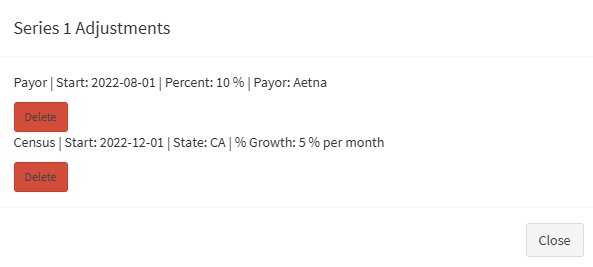

## Adjustment Details Panel

This panel provides a quick summary of all active adjustments applied to the **currently selected projection series**.

---

### What It Shows

Each adjustment is listed with:

- **Type**: Payor or Census
- **Target Scope**: The affected Payors, Procedure Codes, and States
- **Start Date**: When the adjustment begins taking effect
- **Change Type**: Either a percentage (% Change) or flat value (Flat Change)

---

### Example Breakdown

#### Payor Adjustments

- `Payor: All | Code: All | State: All | Start: 2020-01-01 | %: 10%`  
  > Applies a **10% increase** to all payors, codes, and states starting January 2020.

- `Payor: Amerihealth, BCBS, Cigna, Humana... | Code: 70551, 70791, ... | State: All | Start: 2020-01-01 | %: 10%`  
  > Targets a **specific group of payors and procedure codes**, applying a 10% revenue adjustment beginning in January 2020.

#### Census Adjustments

- `Census | State: NY | Start: 2020-01-01 | % Change: -1%`  
- `Census | State: NY | Start: 2020-01-01 | % Change: -3%`  
  > Both of these apply compounding **monthly patient reductions** in New York.  
  > Their effects are cumulative across months.

- `Census | State: CA | Start: 2020-01-01 | Flat Change: 1000`  
  > Adds **1,000 patients per month** to California starting January 2020.

---

### Purpose

This panel offers:

- A **clear overview** of your applied scenario logic.
- Easy reference when comparing projection outcomes.
- Insight into **how each change contributes** to the overall impact chart.

Use this window to **verify inputs** or identify adjustments to modify or delete.


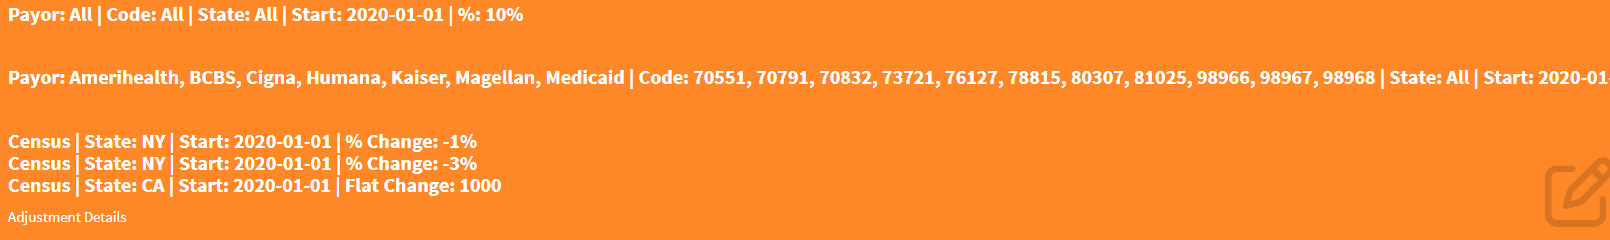

### Detailed Table View

At the bottom of the dashboard, a **detailed data table** displays the underlying dataset used throughout the report.

- Each row represents a unique record tied to a combination of **date, payor, product, procedure, and facility**.
- The table includes columns for key values such as **Billed**, **Expected**, **Paid**, and **Unique Patients**.
- Users can **search, sort, and paginate** the data for deeper analysis.
- This view provides transparency and allows users to validate totals seen in charts above.

This table is especially useful for spot-checking anomalies, exporting specific subsets, or reviewing billing data at a granular level.


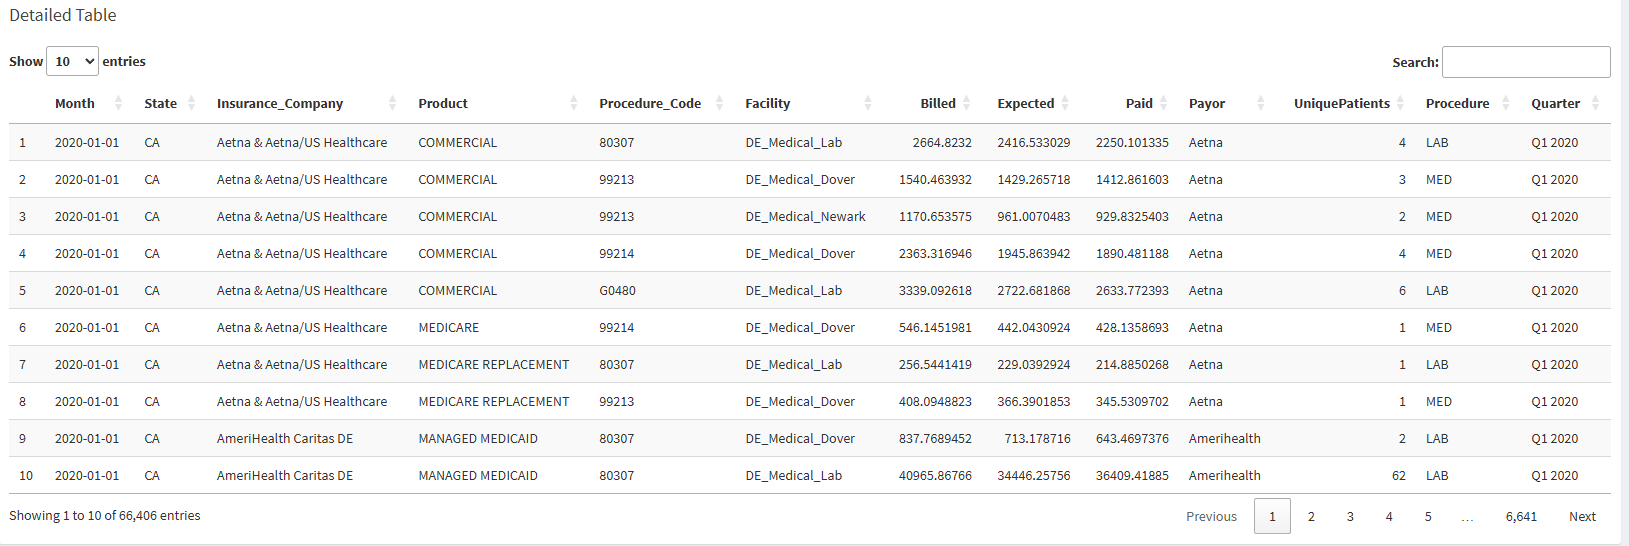